<a href="https://colab.research.google.com/github/RiccoFlores/100-Days-Of-ML-Code/blob/master/NB3_3_Introducci%C3%B3n_a_Operaciones_de_Convoluci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introducción a la Convolución y al Procesamiento Básico en CNN

En esta libreta se introducen cuatro ideas fundamentales que aparecen en redes neuronales convolucionales:

- Convolución
- Filtros verticales y horizontales
- Activación con ReLU
- Condensación mediante Max Pooling

El propósito de este material es desarrollar intuición visual sobre cómo una red convolucional transforma una imagen en mapas de características cada vez más compactos y útiles.

## 1. Preparación del entorno

Primero importamos las bibliotecas que utilizaremos. Trabajaremos con imágenes de ejemplo incluidas en `scikit-learn`, además de `TensorFlow` para aplicar convolución, activación y pooling.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import load_sample_image

También definimos una función sencilla para mostrar imágenes y otra para hacer un recorte de una región de interés. Este recorte nos ayudará a observar mejor el efecto de los filtros en una zona específica.

In [ ]:
def plot_image(image, cmap=None):
    plt.imshow(image, cmap=cmap)
    plt.axis("off")

def crop(image):
    return image[150:220, 130:250]

## 2. Carga de imágenes de ejemplo

Una imagen digital puede representarse como una matriz de números. En imágenes a color, cada pixel tiene tres valores asociados a los canales:

- rojo
- verde
- azul

Usaremos dos imágenes de ejemplo:

- un templo chino
- una flor

Estas imágenes serán suficientes para observar cómo responden los filtros a diferentes estructuras visuales.

In [ ]:
china = load_sample_image("china.jpg") / 255.0
flower = load_sample_image("flower.jpg") / 255.0

images = np.array([china, flower], dtype=np.float32)
images.shape

(2, 427, 640, 3)

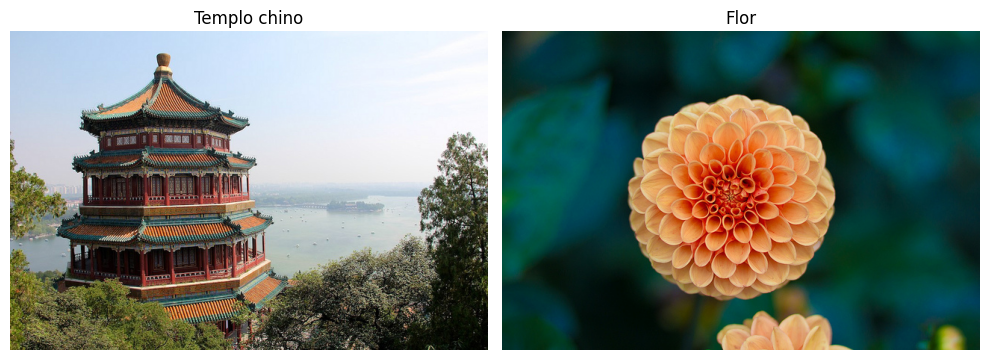

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plot_image(images[0])
plt.title("Templo chino")

plt.subplot(1, 2, 2)
plot_image(images[1])
plt.title("Flor")

plt.tight_layout()
plt.show()

## 3. Concepto de convolución

La **convolución** consiste en recorrer la imagen con una pequeña matriz llamada **filtro** o **kernel**.

En cada posición:

1. se toma una pequeña región de la imagen,
2. se combina con el filtro,
3. y se obtiene un valor numérico.

Al repetir este procedimiento sobre toda la imagen, se genera un nuevo arreglo llamado **mapa de características** o **feature map**.

La idea central es que distintos filtros pueden resaltar distintos patrones, por ejemplo:

- líneas verticales,
- líneas horizontales,
- bordes,
- texturas.

En esta libreta utilizaremos filtros simples definidos manualmente para visualizar con claridad el efecto de la convolución.

## 4. Construcción de filtros vertical y horizontal

Definiremos dos filtros de tamaño `7 x 7`:

- un filtro vertical, que responde con mayor intensidad a estructuras verticales,
- un filtro horizontal, que responde con mayor intensidad a estructuras horizontales.

Como las imágenes son a color, el filtro se aplica sobre los tres canales al mismo tiempo.

In [ ]:
images.shape

(2, 427, 640, 3)

In [ ]:
batch_size, height, width, channels = images.shape

filters = np.zeros((7, 7, channels, 2), dtype=np.float32)

filters[:, 3, :, 0] = 1.0
filters[3, :, :, 1] = 1.0

filters.shape

(7, 7, 3, 2)

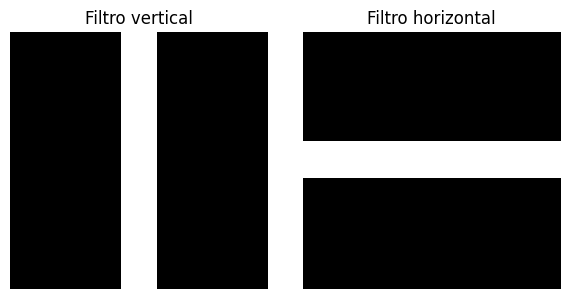

In [ ]:
plt.figure(figsize=(6, 3))

plt.subplot(1, 2, 1)
plot_image(filters[:, :, 0, 0], cmap="gray")
plt.title("Filtro vertical")

plt.subplot(1, 2, 2)
plot_image(filters[:, :, 0, 1], cmap="gray")
plt.title("Filtro horizontal")

plt.tight_layout()
plt.show()

## 5. Aplicación de la convolución

Ahora aplicamos los filtros a las dos imágenes usando la operación `conv2d`.

Usaremos:

- `strides=1`, para desplazar el filtro un pixel a la vez,
- `padding="SAME"`, para conservar el tamaño espacial de la imagen de salida.

La salida tendrá dos mapas de características por imagen:

- uno asociado al filtro vertical,
- otro asociado al filtro horizontal.

In [ ]:
outputs = tf.nn.conv2d(images, filters, strides=1, padding="SAME")
outputs.shape

TensorShape([2, 427, 640, 2])

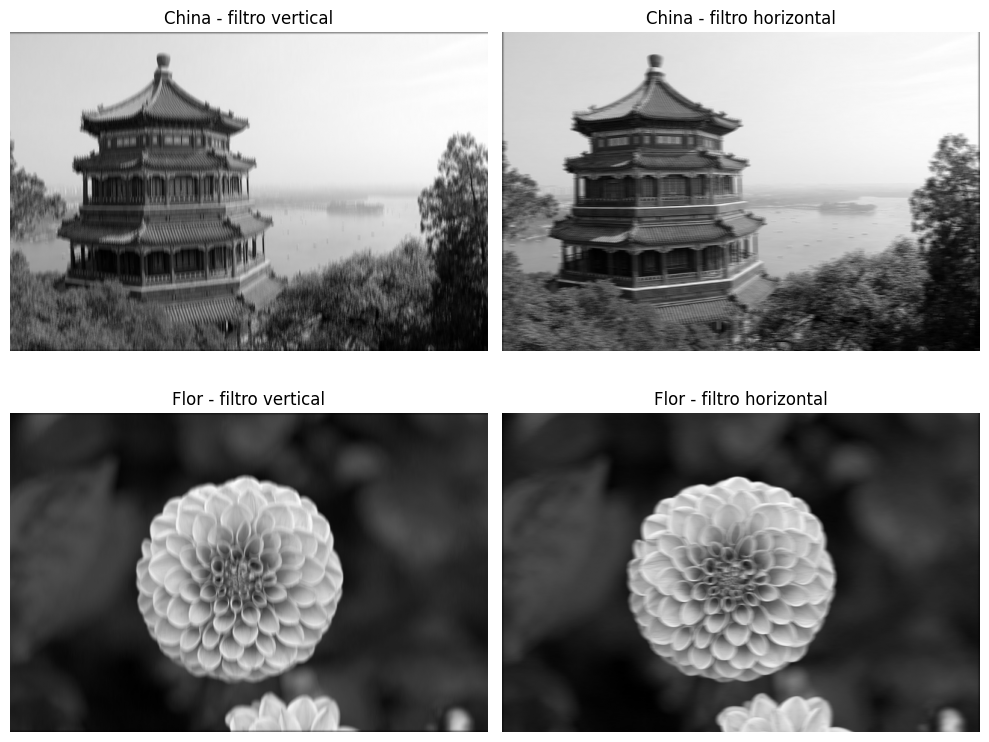

In [ ]:
plt.figure(figsize=(10, 8))

for image_index in (0, 1):
    for feature_map_index in (0, 1):
        plt.subplot(2, 2, image_index * 2 + feature_map_index + 1)
        plot_image(outputs[image_index, :, :, feature_map_index].numpy(), cmap="gray")

        if image_index == 0 and feature_map_index == 0:
            plt.title("China - filtro vertical")
        elif image_index == 0 and feature_map_index == 1:
            plt.title("China - filtro horizontal")
        elif image_index == 1 and feature_map_index == 0:
            plt.title("Flor - filtro vertical")
        else:
            plt.title("Flor - filtro horizontal")

plt.tight_layout()
plt.show()

En estos mapas de características, las zonas más brillantes corresponden a regiones donde el filtro encontró un patrón parecido a su estructura.

Para apreciar mejor el resultado, conviene revisar una región más pequeña de la imagen del templo.

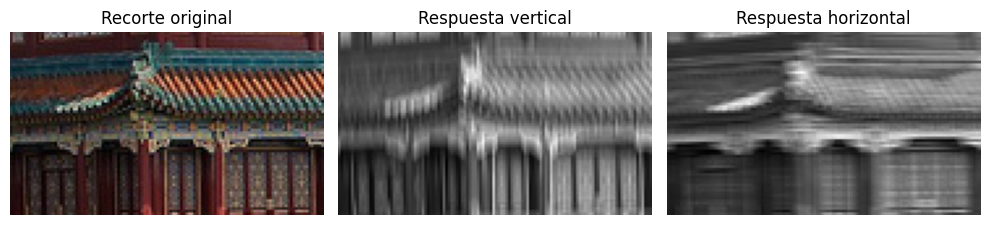

In [ ]:
plt.figure(figsize=(10, 3))

plt.subplot(1, 3, 1)
plot_image(crop(images[0]))
plt.title("Recorte original")

plt.subplot(1, 3, 2)
plot_image(crop(outputs[0, :, :, 0].numpy()), cmap="gray")
plt.title("Respuesta vertical")

plt.subplot(1, 3, 3)
plot_image(crop(outputs[0, :, :, 1].numpy()), cmap="gray")
plt.title("Respuesta horizontal")

plt.tight_layout()
plt.show()

## 6. Activación con ReLU

Después de una convolución, es común aplicar una función de activación. Una de las más utilizadas es **ReLU**, definida como:

\[
\mathrm{ReLU}(x) = \max(0, x)
\]

Su comportamiento es muy simple:

- si el valor es positivo, se conserva;
- si el valor es negativo, se reemplaza por cero.

Esto permite conservar respuestas fuertes y suprimir respuestas negativas. En la práctica, ReLU introduce no linealidad y ayuda a destacar activaciones útiles.

In [ ]:
relu_outputs = tf.nn.relu(outputs)

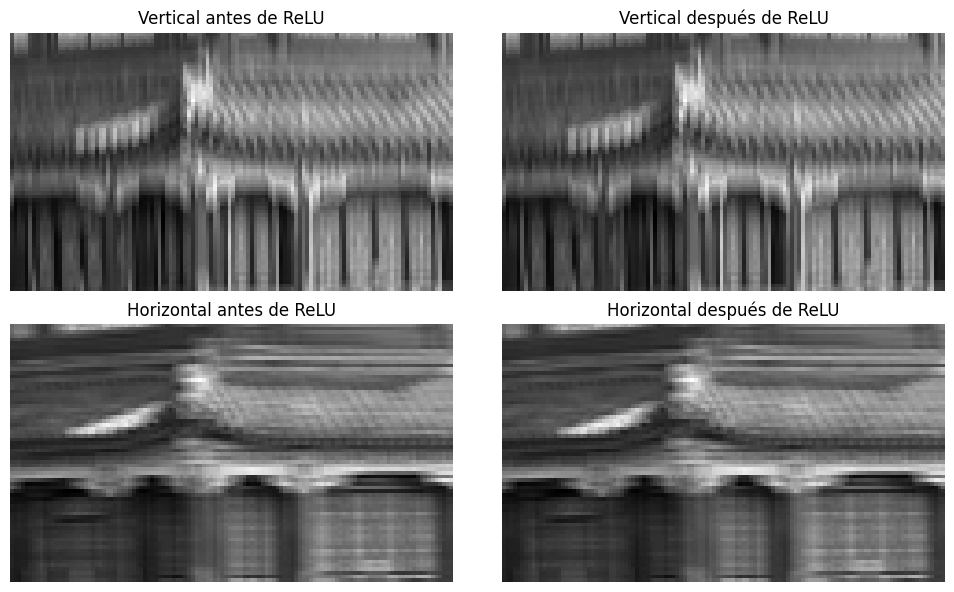

In [ ]:
plt.figure(figsize=(10, 6))

plt.subplot(2, 2, 1)
plot_image(crop(outputs[0, :, :, 0].numpy()), cmap="gray")
plt.title("Vertical antes de ReLU")

plt.subplot(2, 2, 2)
plot_image(crop(relu_outputs[0, :, :, 0].numpy()), cmap="gray")
plt.title("Vertical después de ReLU")

plt.subplot(2, 2, 3)
plot_image(crop(outputs[0, :, :, 1].numpy()), cmap="gray")
plt.title("Horizontal antes de ReLU")

plt.subplot(2, 2, 4)
plot_image(crop(relu_outputs[0, :, :, 1].numpy()), cmap="gray")
plt.title("Horizontal después de ReLU")

plt.tight_layout()
plt.show()

Podemos observar ReLU también en un ejemplo numérico sencillo.

In [ ]:
x = tf.constant([[-2.0, -0.5, 0.0, 1.2, 3.4]])
print("Entrada:")
print(x.numpy())

print("\nSalida después de ReLU:")
print(tf.nn.relu(x).numpy())

Entrada:
[[-2.  -0.5  0.   1.2  3.4]]

Salida después de ReLU:
[[0.  0.  0.  1.2 3.4]]


### Detección de bordes con convolución

Hasta ahora hemos visto filtros simples. Sin embargo, en visión computacional es común utilizar filtros diseñados específicamente para detectar bordes.

Un borde representa un cambio abrupto en la intensidad de la imagen, y es una de las características más importantes para identificar estructuras.

A continuación utilizaremos dos filtros clásicos:
- Detector de bordes verticales
- Detector de bordes horizontales

Estos filtros generan valores positivos y negativos, lo que permitirá observar claramente el efecto de la función de activación ReLU.

In [ ]:
# Filtros tipo Sobel simplificados para bordes

filters_edges = np.zeros((3, 3, channels, 2), dtype=np.float32)

# Filtro vertical
filters_edges[:, :, :, 0] = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])[:, :, np.newaxis]

# Filtro horizontal
filters_edges[:, :, :, 1] = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
])[:, :, np.newaxis]

In [ ]:
outputs_edges = tf.nn.conv2d(images, filters_edges, strides=1, padding="SAME")

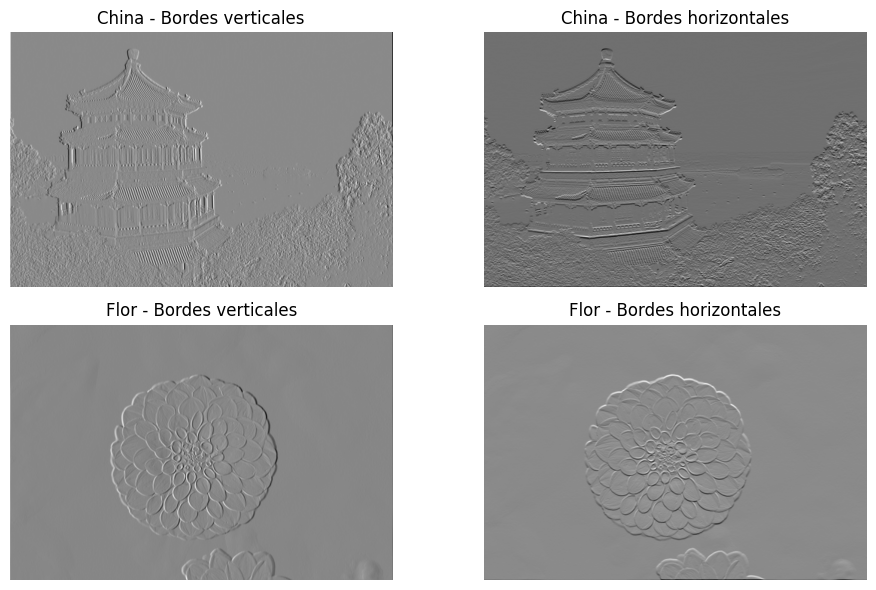

In [ ]:
plt.figure(figsize=(10, 6))

for image_index in (0, 1):
    for feature_map_index in (0, 1):
        plt.subplot(2, 2, image_index * 2 + feature_map_index + 1)
        plot_image(outputs_edges[image_index, :, :, feature_map_index].numpy(), cmap="gray")

        if image_index == 0 and feature_map_index == 0:
            plt.title("China - Bordes verticales")
        elif image_index == 0 and feature_map_index == 1:
            plt.title("China - Bordes horizontales")
        elif image_index == 1 and feature_map_index == 0:
            plt.title("Flor - Bordes verticales")
        else:
            plt.title("Flor - Bordes horizontales")

plt.tight_layout()
plt.show()

In [ ]:
relu_edges = tf.nn.relu(outputs_edges)

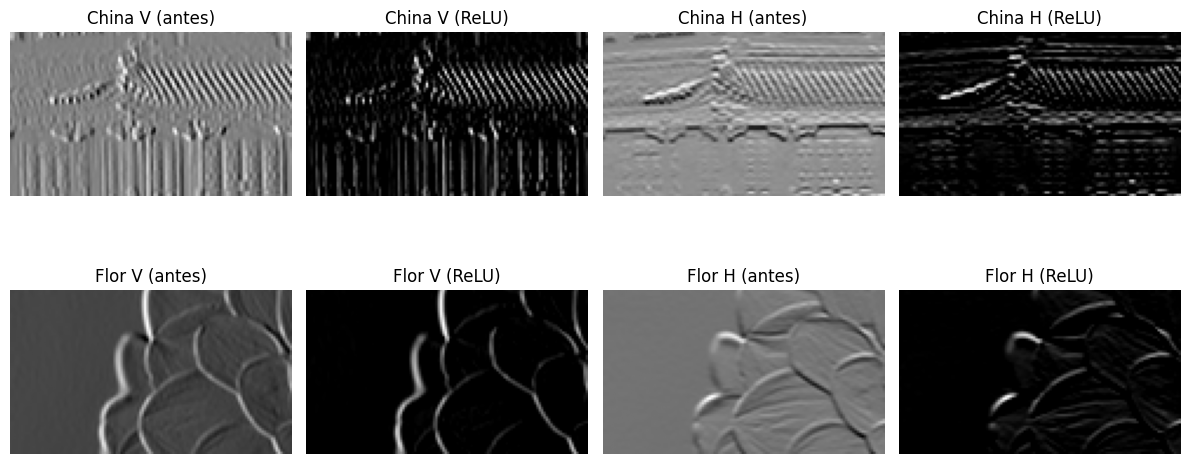

In [ ]:
plt.figure(figsize=(12, 6))

# -------- CHINA --------
plt.subplot(2, 4, 1)
plot_image(crop(outputs_edges[0, :, :, 0].numpy()), cmap="gray")
plt.title("China V (antes)")

plt.subplot(2, 4, 2)
plot_image(crop(relu_edges[0, :, :, 0].numpy()), cmap="gray")
plt.title("China V (ReLU)")

plt.subplot(2, 4, 3)
plot_image(crop(outputs_edges[0, :, :, 1].numpy()), cmap="gray")
plt.title("China H (antes)")

plt.subplot(2, 4, 4)
plot_image(crop(relu_edges[0, :, :, 1].numpy()), cmap="gray")
plt.title("China H (ReLU)")

# -------- FLOR --------
plt.subplot(2, 4, 5)
plot_image(crop(outputs_edges[1, :, :, 0].numpy()), cmap="gray")
plt.title("Flor V (antes)")

plt.subplot(2, 4, 6)
plot_image(crop(relu_edges[1, :, :, 0].numpy()), cmap="gray")
plt.title("Flor V (ReLU)")

plt.subplot(2, 4, 7)
plot_image(crop(outputs_edges[1, :, :, 1].numpy()), cmap="gray")
plt.title("Flor H (antes)")

plt.subplot(2, 4, 8)
plot_image(crop(relu_edges[1, :, :, 1].numpy()), cmap="gray")
plt.title("Flor H (ReLU)")

plt.tight_layout()
plt.show()

Observa cómo antes de aplicar ReLU aparecen tanto valores positivos como negativos en el mapa de características.

Después de aplicar ReLU, solo se conservan las activaciones positivas, lo que resalta los bordes más relevantes y elimina información menos útil.

Este comportamiento es fundamental en redes neuronales convolucionales, ya que permite enfocarse en las características más importantes de la imagen.

## 7. Condensación con Max Pooling

Una vez obtenidos los mapas de características, es frecuente reducir su tamaño mediante una operación de **pooling**.

En particular, el **max pooling** divide el mapa en pequeñas regiones, por ejemplo de `2 x 2`, y conserva únicamente el valor máximo de cada región.

Esto tiene varias ventajas:

- reduce dimensiones,
- mantiene las respuestas más intensas,
- hace más eficiente el procesamiento posterior.

Aplicaremos una capa de `MaxPool2D` con ventana de tamaño 2.

In [ ]:
max_pool = tf.keras.layers.MaxPool2D(pool_size=2)
pooled = max_pool(relu_outputs)
pooled.shape

TensorShape([2, 213, 320, 2])

In [ ]:
def crop_pooled(image):
    return image[75:110, 65:125]

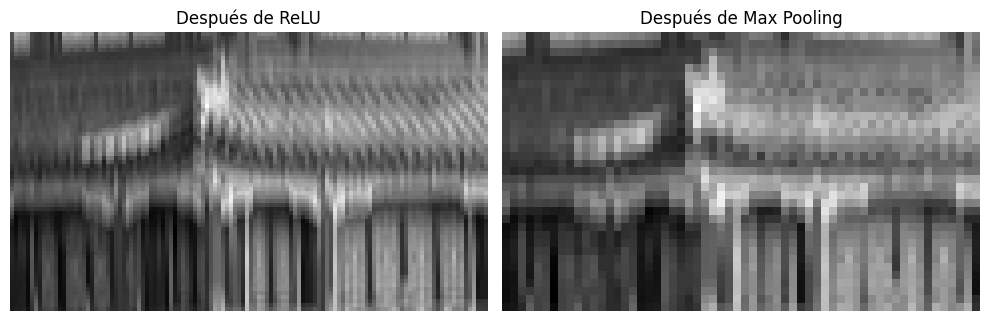

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plot_image(crop(relu_outputs[0, :, :, 0].numpy()), cmap="gray")
plt.title("Después de ReLU")

plt.subplot(1, 2, 2)
plot_image(crop_pooled(pooled[0, :, :, 0].numpy()), cmap="gray")
plt.title("Después de Max Pooling")

plt.tight_layout()
plt.show()

También es útil comparar el efecto del max pooling directamente sobre una región visible de la imagen.

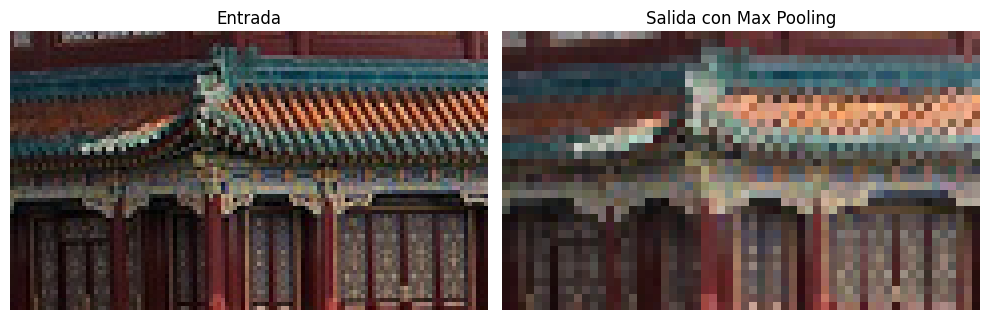

In [ ]:
cropped_images = np.array([crop(image) for image in images], dtype=np.float32)
cropped_pooled = max_pool(cropped_images)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plot_image(cropped_images[0])
plt.title("Entrada")

plt.subplot(1, 2, 2)
plot_image(cropped_pooled[0])
plt.title("Salida con Max Pooling")

plt.tight_layout()
plt.show()

## 8. Flujo conceptual completo

Hasta aquí hemos visto una secuencia típica del procesamiento en una red convolucional:

1. **Imagen de entrada**
2. **Convolución con filtros**
3. **Mapa de características**
4. **Activación con ReLU**
5. **Reducción con Max Pooling**

Este flujo puede resumirse así:

**imagen > convolución > activación > pooling**

La intuición que se busca desarrollar es la siguiente:

- la convolución detecta patrones locales,
- ReLU conserva activaciones útiles,
- max pooling compacta la información más importante.

Estas operaciones son la base sobre la cual se construyen arquitecturas convolucionales más profundas.